# Regression de la note donnée à un vin

## Nettoyage des données

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd


KeyboardInterrupt: 

Première visualisation des données

In [62]:
df = pd.read_csv("data/winemag-data-130k-v2.csv")
print("nombre d'entrée: "+str(df.shape[0]) + "| nombre de charactéristiques: " +str(df.shape[1]))
print("nom des charactéristiques: "+ str(df.columns))

nombre d'entrée: 129971| nombre de charactéristiques: 14
nom des charactéristiques: Index(['id', 'country', 'description', 'designation', 'points', 'price',
       'province', 'region_1', 'region_2', 'taster_name',
       'taster_twitter_handle', 'title', 'variety', 'winery'],
      dtype='str')


In [63]:
NB_COUNTRY = 15
NB_PROVINCE = 40
NB_VARIETY = 40
NB_WINERY = 40

MIN_COUNTRY = df['country'].value_counts().iloc[NB_COUNTRY - 1]
MIN_PROVINCE = df['province'].value_counts().iloc[NB_PROVINCE - 1]
MIN_VARIETY = df['variety'].value_counts().iloc[NB_VARIETY - 1]
MIN_WINERY = df['winery'].value_counts().iloc[NB_WINERY - 1]


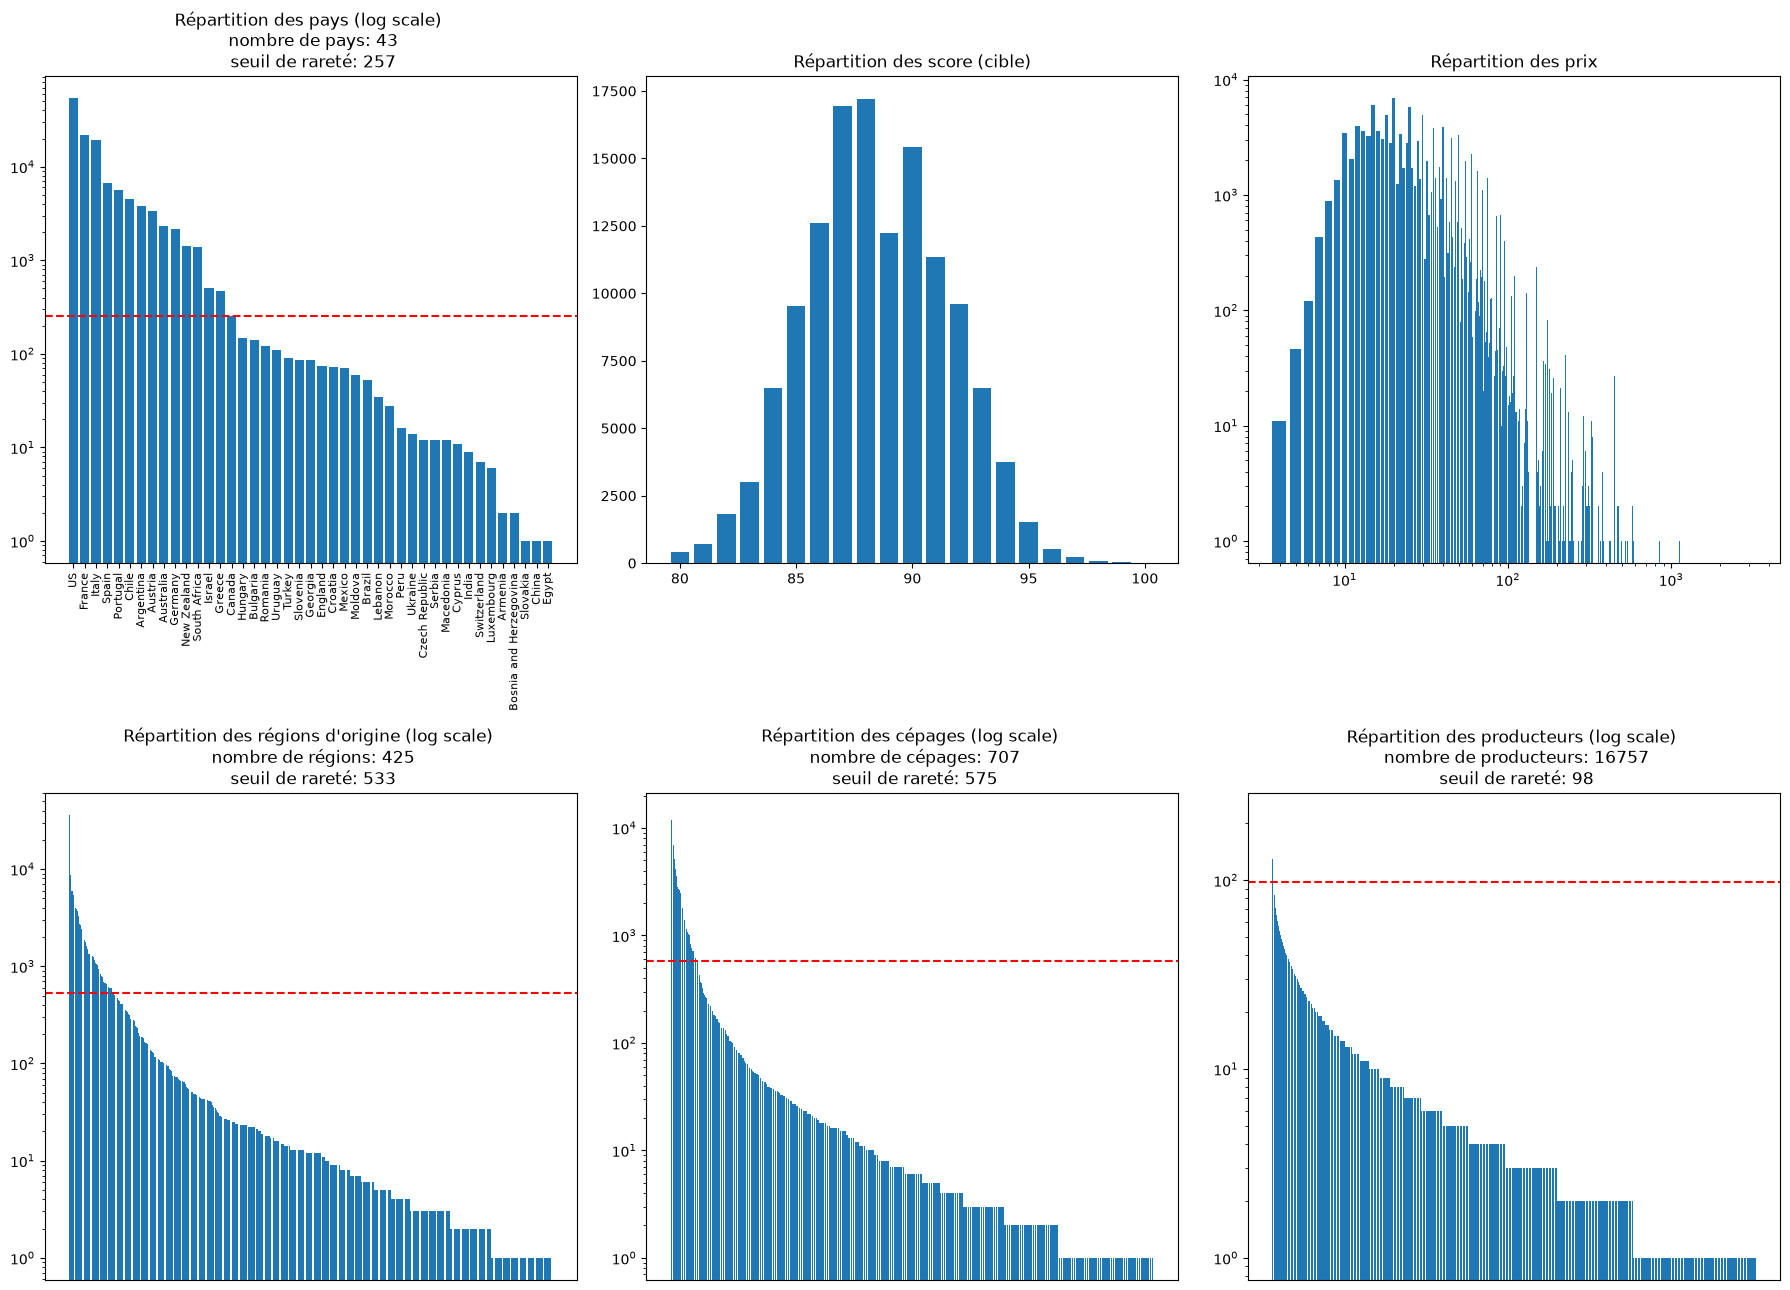

In [64]:
plt.figure(figsize=(18,13))

plt.subplot(2,3,1)
plt.bar(df['country'].value_counts().index, df['country'].value_counts())
plt.yscale("log")
plt.xticks(rotation=90, fontsize=8)
plt.axhline(
    y=MIN_COUNTRY,
    color='red',
    linestyle='--'
)
plt.title("Répartition des pays (log scale) \n nombre de pays: " + str(df['country'].nunique()) + "\n seuil de rareté: " + str(MIN_COUNTRY))


plt.subplot(2,3,2)
plt.bar(df['points'].value_counts().index, df['points'].value_counts())
plt.title("Répartition des score (cible)")

plt.subplot(2,3,3)
plt.bar(df['price'].value_counts().index, df['price'].value_counts())
plt.title("Répartition des prix")
plt.yscale("log")
plt.xscale("log")

plt.subplot(2,3,4)
plt.bar(df['province'].value_counts().index, df['province'].value_counts())
plt.yscale("log")
plt.xticks([])
plt.axhline(
    y=MIN_PROVINCE,
    color='red',
    linestyle='--'
)
plt.title("Répartition des régions d'origine (log scale) \n nombre de régions: " + str(df['province'].nunique()) + "\n seuil de rareté: " + str(MIN_PROVINCE))


plt.subplot(2,3,5)
plt.bar(df['variety'].value_counts().index, df['variety'].value_counts())
plt.yscale("log")
plt.xticks([])
plt.axhline(
    y=MIN_VARIETY,
    color='red',
    linestyle='--'
)
plt.title("Répartition des cépages (log scale) \n nombre de cépages: " + str(df['variety'].nunique()) + "\n seuil de rareté: " + str(MIN_VARIETY))


plt.subplot(2,3,6)
plt.bar(df['winery'].value_counts().index, df['winery'].value_counts())
plt.yscale("log")
plt.axhline(
    y=MIN_WINERY,
    color='red',
    linestyle='--'
)
plt.title("Répartition des producteurs (log scale) \n nombre de producteurs: " + str(df['winery'].nunique()) + "\n seuil de rareté: " + str(MIN_WINERY))
plt.xticks([])

plt.tight_layout()





In [65]:
print("charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques")

for s in df.columns:
    print("< " + s + " >  | " + str(df[s].isna().sum()) + " | " + str(round(df[s].isna().sum()/df.shape[0]*100, 2)) + "% | " + str(df[s].nunique()))



charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques
< id >  | 0 | 0.0% | 129971
< country >  | 63 | 0.05% | 43
< description >  | 0 | 0.0% | 119955
< designation >  | 37465 | 28.83% | 37976
< points >  | 0 | 0.0% | 21
< price >  | 8996 | 6.92% | 390
< province >  | 63 | 0.05% | 425
< region_1 >  | 21247 | 16.35% | 1229
< region_2 >  | 79460 | 61.14% | 17
< taster_name >  | 26244 | 20.19% | 19
< taster_twitter_handle >  | 31213 | 24.02% | 15
< title >  | 0 | 0.0% | 118840
< variety >  | 1 | 0.0% | 707
< winery >  | 0 | 0.0% | 16757


"taster_twitter_handle" est inutile ici
<br>"designation" présente trop de valeur vide + trop différentes.
<br>"title" est le nom du vin, trop de valeurs différentes ici
<br>"region_2" présente trop de valeur absente et "region_1" n'est qu'une précision sur "province" qui présente déjà beacoup de valeurs
<br>"id" ne peut pas non plus être donné au modèle

In [66]:
df = df.drop(columns=['designation', 'taster_twitter_handle', 'title','region_2','region_1','id'])

On va regrouper les valeur de charactéristiques les plus rares et remplacer les valeurs manquantes:

In [67]:
nb_lignes_pays_rares = df['country'].value_counts().loc[lambda counts: counts < MIN_COUNTRY].sum()
print("Nombre de lignes correspondant aux pays rares :", nb_lignes_pays_rares)

nb_lignes_province_rares = df['province'].value_counts().loc[lambda counts: counts < MIN_PROVINCE].sum()
print("Nombre de lignes correspondant aux régions rares :", nb_lignes_province_rares)

nb_lignes_variety_rares = df['variety'].value_counts().loc[lambda counts: counts < MIN_VARIETY].sum()
print("Nombre de lignes correspondant aux cépages rares :", nb_lignes_variety_rares)

nb_lignes_winery_rares = df['winery'].value_counts().loc[lambda counts: counts < MIN_WINERY].sum()
print("Nombre de lignes correspondant aux producteurs rares :", nb_lignes_winery_rares)

Nombre de lignes correspondant aux pays rares : 1276
Nombre de lignes correspondant aux régions rares : 15834
Nombre de lignes correspondant aux cépages rares : 18173
Nombre de lignes correspondant aux producteurs rares : 124549


Même en les regroupant, il y a trop de producteurs, on va donc les retirer

In [68]:
df = df.drop(columns=['winery'])

In [69]:
df["country"] = df["country"].mask(df["country"].isin(df["country"].value_counts()[df["country"].value_counts() < MIN_COUNTRY].index))
df["province"] = df["province"].mask(df["province"].isin(df["province"].value_counts()[df["province"].value_counts() < MIN_PROVINCE].index))
df["variety"] = df["variety"].mask(df["variety"].isin(df["variety"].value_counts()[df["variety"].value_counts() < MIN_VARIETY].index))

In [70]:
df["country"] = df["country"].fillna("Other")
df["province"] = df["province"].fillna("Other")
df["variety"] = df["variety"].fillna("Other")

df["taster_name"] = df["taster_name"].fillna("Other")

# ON REMPLACE LES VALEURS MANQUANTES DU PRIX PAR LA MOYENNE DES PRIX
df["price"] = df["price"].fillna(format(df["price"].mean(), ".1f"))

#POUR L'INSTANT ON SUPPRIME LES DESCRIPTIONS
df = df.drop(columns=['description'])

In [71]:
print("charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques")

for s in df.columns:
    print("< " + s + " >  | " + str(df[s].isna().sum()) + " | " + str(round(df[s].isna().sum()/df.shape[0]*100, 2)) + "% | " + str(df[s].nunique()))


charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques
< country >  | 0 | 0.0% | 16
< points >  | 0 | 0.0% | 21
< price >  | 0 | 0.0% | 391
< province >  | 0 | 0.0% | 40
< taster_name >  | 0 | 0.0% | 20
< variety >  | 0 | 0.0% | 41


In [72]:
df.to_csv("data/wine_cleaned_no_desc.csv", index=False)

----------------------
## Premiers algos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import tqdm 
import xgboost as xgb

In [2]:
df = pd.read_csv("data/wine_cleaned_no_desc.csv")

X=np.concatenate([df.values[:,0].reshape(-1,1), df.values[:,3:]], axis=1)
X_prix=df.values[:,2].reshape(-1,1)
Y=df.values[:,1].reshape(-1,1)

One_hot_encoding pour les descripteurs qui en ont besoins:

In [3]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


X = enc.fit_transform(X)
X = np.concatenate([X, X_prix], axis=1)
# print("Catégories trouvées, colonne par colonne: \n", enc.categories_)
print("Echantillon transformé: \n", X[0,:], Y[0])


Echantillon transformé: 
 [0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 35.4] [87]


Split en 2 jeu: train et test:

In [4]:
Xtrain, Xtest, Ytrain, Ytest = sklearn.model_selection.train_test_split(X, Y, test_size=0.2, random_state=42)

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
}

gs = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=1),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True,
)
gs.fit(Xtrain, Ytrain)

print("Meilleurs paramètres :", gs.best_params_)
print(f"RMSE CV : {-gs.best_score_:.2f}")

# Évaluation unique sur le test, avec le meilleur modèle (déjà réentraîné sur tout Xtrain)
y_pred = gs.best_estimator_.predict(Xtest).ravel()
rmse = np.sqrt(mean_squared_error(Ytest, y_pred))
print(f"RMSE test : {rmse:.2f}")

# Tableau de tous les essais
resultats = (
    pd.DataFrame(gs.cv_results_)
    .assign(rmse=lambda d: -d['mean_test_score'])
    .sort_values('rmse')
    [['params', 'rmse', 'std_test_score']]
)
print(resultats.head(10))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
RMSE CV : 2.21
RMSE test : 2.20
                                               params      rmse  \
22  {'learning_rate': 0.1, 'max_depth': 7, 'n_esti...  2.207922   
23  {'learning_rate': 0.1, 'max_depth': 7, 'n_esti...  2.210877   
10  {'learning_rate': 0.05, 'max_depth': 7, 'n_est...  2.215664   
18  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...  2.217632   
11  {'learning_rate': 0.05, 'max_depth': 7, 'n_est...  2.221763   
19  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...  2.222612   
20  {'learning_rate': 0.1, 'max_depth': 7, 'n_esti...  2.228461   
21  {'learning_rate': 0.1, 'max_depth': 7, 'n_esti...  2.230945   
6   {'learning_rate': 0.05, 'max_depth': 5, 'n_est...  2.237913   
7   {'learning_rate': 0.05, 'max_depth': 5, 'n_est...  2.243008   

    std_test_score  
22        0.013476  
23        0.012693  
10  

In [7]:
from sklearn.metrics import mean_squared_error


bst = xgb.XGBRegressor(learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8, random_state=42)
bst.fit(Xtrain, Ytrain)
y_pred = bst.predict(Xtest)


y_pred = bst.predict(Xtest).ravel()

rmse = np.sqrt(mean_squared_error(Ytest, y_pred))
print(f"RMSE: {rmse:.2f}")


RMSE: 2.20


[[80.         81.42218018]
 [80.         82.18682098]
 [80.         82.30496979]
 [80.         82.55448151]
 [80.         82.67428589]
 [80.         82.74385834]
 [80.         82.75289917]
 [80.         82.76460266]
 [80.         82.79505157]
 [80.         82.81162262]]


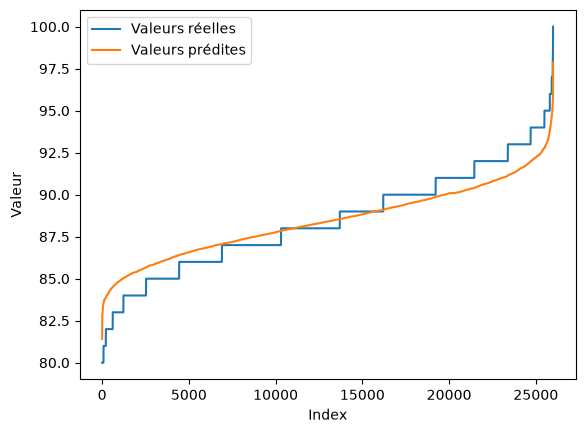

In [8]:
linked = np.sort(np.array([[yt[0],yp] for yt, yp in zip(Ytest, y_pred)]),axis=0)
print(linked[:10])


plt.plot(linked[:, 0], label="Valeurs réelles")
plt.plot(linked[:, 1], label="Valeurs prédites")


plt.xlabel("Index")
plt.ylabel("Valeur")
plt.legend()
plt.show()
